# Wumpus World: From Percepts to Proofs

- This notebook builds a knowledge-based agent for the classic wumpus world
  and uses it to make the model-theoretic definition of entailment concrete
- The pedagogical arc:
  - Percepts and a knowledge base (`KB`) built with `TELL`
  - Models, `M(KB)`, and entailment as set inclusion
  - Implication vs entailment vs inference
  - Soundness and completeness, seen by deliberately breaking each
  - Model checking vs a SAT solver as the state space grows
  - Propositional rules rewritten as first-order sentences
  - A full agent loop that ties every piece together

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
!pip install -q sympy==1.14.0

import sympy
print("sympy version: ", sympy.__version__)

In [2]:
import helpers.hnotebook as hnotebook

import L03_02_wumpus_world_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

INFO  > /usr/local/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-d45e243a-a7da-44a7-846f-1f182a04273c.json


# Part 1: Percepts and the Knowledge Base

## The Wumpus World Problem

- A 4x4 grid holds a hidden layout, unknown to the agent at the start:
  - Some cells hold a _pit_: stepping into one kills the agent
  - One cell holds the _wumpus_: stepping into it, or the wumpus moving into
    the agent, also kills the agent
  - One cell holds the _gold_: the agent's goal is to grab it and return to
    the start cell `(1, 1)`, which is always safe
- The agent cannot see the grid directly, only local percepts in the cell
  it currently occupies:
  - _Breeze_: at least one adjacent cell holds a pit
  - _Stench_: at least one adjacent cell holds the wumpus
  - _Glitter_: the current cell holds the gold
- **The breeze axiom**:
  - The rule linking the breeze percept to its hidden cause is a
    biconditional: a cell has a _breeze_ if and only if at least one of its
    neighbors has a pit
  - E.g., for cell $(1, 2)$ with neighbors $(1, 1)$, $(1, 3)$, $(2, 2)$:
    $B_{1,2} \Leftrightarrow (P_{1,1} \lor P_{1,3} \lor P_{2,2})$
  - One such axiom exists for every cell in the grid, told into the `KB`
    only once that cell's percept has actually been observed

## The Correct Strategy to Win

- Never move into a cell unless the `KB` proves it safe:
  - No pit: `KB` entails `Not(P_cell)`, checked by model checking or `ASK`
  - No wumpus: `cell` is not a stench suspect, a cell every observed
    stench is consistent with
  - Guessing based on the hidden truth is not allowed: only `TELL`-ed
    percepts and their logical consequences count
- Grow the `KB` one step at a time:
  - Move to a cell already proven safe
  - `TELL` its percept, then check whether each unvisited neighbor is now
    provably safe
  - Repeat until the gold's cell is provably reachable through safe cells
- Grab the gold once its cell is reached (its `glitter` percept fires),
  then retrace safe cells back to the start to win
- A cell that is merely undetermined (`KB` neither proves nor disproves a
  pit) is not safe: entering it is a gamble, not a proof
- Part 4 implements exactly this loop: `cell4_2_agent_loop` only ever
  steps to a cell the `KB` has proved pit-free and that no stench
  implicates as the wumpus

## Cell 1.1: The Wumpus World Grid and the Knowledge Base

**Goal**:
- Give students a concrete grid to reason about before any logic is
  introduced
- Show that a knowledge-based agent knows only what it has been `TELL`-ed,
  not the hidden truth of the world

**Explanation of Widget**
- _Hidden world_: 4x4 grid with pits, the wumpus, and gold shown as icons on
  one panel
- _KB view_: the agent's current `KB` (told percepts only) on the adjacent
  panel
- _Comments_: current cell clicked, percept just told, total number of facts
  in the `KB`

In [11]:
# Click a cell, then TELL its percept, and watch the KB panel catch up.
utils.cell1_1_world_and_kb()

**Key observations**:
- The left panel (truth) and the right panel (`KB`) disagree almost
  everywhere at first: the agent starts knowing almost nothing
- The agent knows only what it has been `TELL`-ed, never the hidden truth
  in the left panel
- `TELL percept` adds up to three sentences to the `KB`, and nothing is
  ever removed:
  - `Not(P_cell)`: the agent stood in the cell and survived, so no pit
  - The breeze axiom for the cell, the biconditional linking its breeze
    percept to its neighboring pits
  - The observed breeze literal, true or false, from `world.percept(cell)`
- The gap between the two panels is exactly the reasoning problem the rest
  of the notebook solves

### Example of Reasoning

- Start at (1,1) and visit it
- (2,1) and (1,2) are neighbors of (1,1), the only visited cell
- Percept at (1,1): no breeze
- TELL percept((1,1)) adds:
  - Not(P_1_1): no pit here (agent survived)
  - Breeze axiom: B_1_1 <=> (P_2_1 | P_1_2)
  - Not(B_1_1): observed, no breeze felt
- Model checking combines these: Not(B_1_1) forces (P_2_1 | P_1_2) false
- So both P_2_1 and P_1_2 are false: no pit at (2,1), no pit at (1,2)

KB proves this by inference. Agent never stepped into (2,1) or (1,2).

- Blue = actually visited
  - Only (1,1) is blue
- Green = proved pit-free by entailment
   - (2,1) and (1,2) are green but not blue: proof, not observation.

# Part 2: Models and Entailment

## Cell 2.1: Models and the Breeze Axiom

We need to understand what entailment means formally. Part 1 built a `KB` from percepts; this part makes precise what the agent can conclude from it. A sentence α is entailed by the `KB` exactly when every model (every possible world) consistent with the `KB` also makes α true. This part introduces models concretely, so that entailment can later be checked directly as $M(KB) \subseteq M(\alpha)$.

**Goal**:
- Introduce a model as one full true/false assignment to every pit variable
- Encode the breeze axiom
  $B_{1,2} \Leftrightarrow (P_{1,1} \lor P_{2,2} \lor P_{1,3})$

- The KB is:
    1. Breeze axiom: Equivalent(B_1_2, P_1_1 | P_1_3 | P_2_2)
    2. B_1_2: a breeze was observed at (1, 2)
    3. Not(P_1_1): agent started at (1, 1), survived, no pit

**Explanation of Widget**
- _Model table_: all $2^3$ rows of a truth table over the axiom's own pit
  variables, with rows satisfying the `KB` shaded
- _Comments_: number of candidate models, number shaded, and the `KB`
  sentences behind the shading

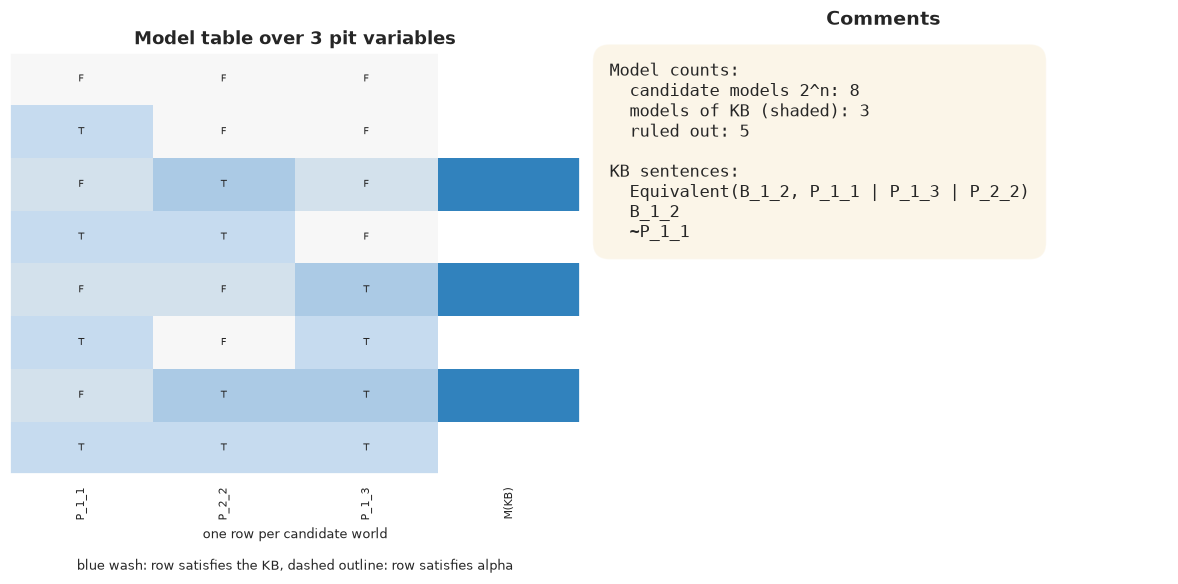

In [12]:
# Enumerate every model of the breeze axiom and shade the ones satisfying it.
utils.cell2_1_models_and_axiom()

**Key observations**:
- $M(KB)$ is the shaded subset of rows in the table
- Adding one more pit variable would double the table: this is the $2^n$
  growth that Cell 3.2 measures directly

## Cell 2.2: Entailment as Model Inclusion

- Same KB as before
    1. Breeze axiom: Equivalent(B_1_2, P_1_1 | P_1_3 | P_2_2)
    2. B_1_2: a breeze was observed at (1, 2)
    3. Not(P_1_1): agent started at (1, 1), survived, no pit

**Goal**:
- Answer questions (e.g., "is cell $(2,2)$ provably safe?") by model checking directly

**Explanation of Widget**
- _Model table_: same table as Cell 2.1, now with a second shading color for
  $M(\alpha)$, so overlap and gaps between the two sets are visible
- _Inclusion counts_: bar chart of $M(KB)$, the overlap, and the
  counterexamples
- _Comments_: query sentence $\alpha$, whether $M(KB) \subseteq M(\alpha)$
  holds, entailment verdict

In [13]:
# Decide KB |= alpha by checking whether M(KB) sits inside M(alpha).
utils.cell2_2_entailment()

**Examples**
- No pit at (1,1): entailed
- Pit at (1,1): contradicted
- No pit at (2,2) is not entailed: there are models where (2,2) has a pit
  and models where it does not, so the KB leaves it undetermined
- Pit at (1,3): contradicted, since no model consistent with the KB has a
  pit there

Each verdict (entailed, contradicted, undetermined) follows from model
inclusion alone, never from guessing or from how the query is phrased.

**Key observations**:
- $KB \models \alpha$ holds only when every `KB`-shaded row is also
  $\alpha$-shaded: a single counterexample row breaks entailment
- Some queries are entailed, some are contradicted, and some are simply
  undetermined by the current `KB`
- Entailment is a property of the full model sets, never of one row alone

## Cell 2.3: Implication, Entailment, and Inference

**Goal**:
- Separate three ideas that are easy to conflate
  - a sentence's internal structure
  - a semantic guarantee across models
  - a computational procedure

**Explanation of Widget**
- _Implication view_: the biconditional sentence itself, with its logical
  connectives highlighted
- _Entailment view_: the same shaded model table from Cell 2.2
- _Inference view_: a step-by-step trace of the procedure walking from `KB`
  to $\alpha$
- _Comments_: which of the three views is active, and its one-line definition

In [14]:
# Toggle between the three views of the same breeze example.
utils.cell2_3_three_views()

**Key observations**:
- Implication lives inside one sentence, entailment lives across all
  models, inference is a procedure a computer actually runs
- A correct inference procedure produces exactly the conclusions entailment
  predicts, no more and no fewer
- A reasoner that gets this correspondence wrong is either unsound (proves
  too much) or incomplete (proves too little)

# Part 3: Soundness, Completeness, and Scaling

In [ ]:
# SAT solver: a decision procedure for Boolean satisfiability. Instead of
# enumerating all 2^n assignments like model checking, it uses unit
# propagation and backtracking search to find a satisfying assignment (or
# prove none exists), pruning large parts of the search space at each step.
# KB |= alpha holds iff KB AND NOT(alpha) is unsatisfiable, so a SAT solver
# answers the same entailment query without ever building M(KB) explicitly.

## Cell 3.2: Model Checking Doesn't Scale

**Goal**:
- Measure how brute-force model checking degrades as the grid grows, and
  compare it against a SAT solver on the same `KB`

**Explanation of Widget**
- _Runtime curve_: log-scale runtime vs grid size (2x2 to 6x6) for model
  checking and for a SAT solver on the same query
- _Comments_: current grid size, number of variables, measured runtime for
  each method

In [16]:
# Compare brute-force model checking against a SAT solver as the grid grows.
utils.cell3_2_scaling(fixed_grid_size=6)

**Key observations**:
- Model-checking runtime grows exponentially with grid size, matching the
  $2^n$ model count from Cell 2.1
- The SAT solver answers the same query far faster by never enumerating
  all models explicitly
- This is the expressiveness vs tractability trade-off from the lecture,
  made visible as a runtime curve rather than a claim

# Part 4: First-Order Logic and the Full Agent

## Cell 4.1: From Propositional Rules to First-Order Sentences

**Goal**:
- Rewrite the propositional breeze axiom as a single first-order sentence
  with a universal quantifier, and instantiate it for a specific cell

**Explanation of Widget**
- _First-order rule_: the sentence
  $\forall x, y \; Breeze(x,y) \Leftrightarrow \exists x', y' \; Adjacent(x,y,x',y') \land Pit(x',y')$
- _Grounded instance_: the grid with the chosen cell's ground literals
  highlighted after universal and existential instantiation
- _Comments_: chosen cell, the ground sentence produced

In [17]:
# Rewrite the breeze axiom as one quantified sentence, then ground it.
utils.cell4_1_first_order()

**Key observations**:
- One first-order sentence replaces 16 separate propositional axioms, one
  per grid cell
- Universal instantiation grounds $x, y$ to the chosen cell; existential
  instantiation then picks a witness among its neighbors
- The grounded sentence is exactly the propositional axiom from Cell 2.1
  for that cell

## Cell 4.2: The Agent Loop: KB Grows, Candidate Models Shrink

**Goal**:
- Tie every prior cell together in a stepping agent that `TELL`s new
  percepts and re-`ASK`s safety at each step

**Explanation of Widget**
- _Agent grid_: current agent position and every percept told so far
- _Candidate model count_: line plot of $|M(KB)|$ after each step, always
  non-increasing
- _Comments_: current step number, last percept told, current $|M(KB)|$

In [18]:
# Step the agent through provably safe cells and watch |M(KB)| shrink.
utils.cell4_2_agent_loop()

**Key observations**:
- Each `TELL` can only remove models from $M(KB)$, never add them
- Confidence about a cell's safety increases exactly as $M(KB)$ shrinks
  toward models that agree on that cell
- This closes the loop from Cell 1.1's raw percepts to a working
  knowledge-based agent

# Summary: The Mental Model

- A knowledge base is a set of sentences built with `TELL`; `ASK` answers a
  query by model checking, comparing $M(KB)$ against $M(\alpha)$
- $KB \models \alpha$ means $M(KB) \subseteq M(\alpha)$: every model
  consistent with what is known also makes $\alpha$ true
- Implication is syntax inside one sentence, entailment is semantics across
  all models, and inference is the algorithm that tries to track entailment
- A sound reasoner never asserts more than entailment supports, and a
  complete reasoner never misses what entailment supports; the two failures
  are independent
- Model checking implements entailment directly but costs $2^n$ time; a SAT
  solver answers the same query without ever enumerating all models
- First-order logic compresses one axiom per grid cell into a single
  quantified sentence, grounded by instantiation